# 02 — Data Cleaning

Load the merged table, understand what's missing and why, then save a clean version to `data/processed/`.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import sys
from pathlib import Path

def find_project_root(start, depth=5):
    path = start.resolve()
    for _ in range(depth):
        if (path / "src").exists() and (path / "requirements.txt").exists():
            return path
        path = path.parent
    raise RuntimeError(f"Can't find project root from {start}")

PROJECT_ROOT  = find_project_root(Path.cwd())
PROCESSED_DIR = PROJECT_ROOT / "data" / "processed"
FIGURES_DIR   = PROJECT_ROOT / "outputs" / "figures"
PROCESSED_DIR.mkdir(parents=True, exist_ok=True)
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

sys.path.insert(0, str(PROJECT_ROOT))
from src.data_loader import load_raw_tables, build_master_df, add_parsed_lap_times
from src.features import build_feature_set, FEATURE_COLUMNS, TARGET_COLUMN

plt.style.use("seaborn-v0_8-darkgrid")
pd.set_option("display.max_columns", 50)
print("Root:", PROJECT_ROOT)

Root: C:\Users\Agam Katiyar\Projects\f1-ml-predictions


## Load master dataframe

In [2]:
tables = load_raw_tables()
df = build_master_df(tables)
df = add_parsed_lap_times(df)
print(df.shape)
df.head(3)

(26759, 38)


,resultId,raceId,driverId,constructorId,number,grid,position,positionText,positionOrder,points,laps,time,milliseconds,fastestLap,rank,fastestLapTime,fastestLapSpeed,statusId,year,round,circuitId,name,driverRef,nationality_driver,dob,constructorRef,nationality_constructor,q1,q2,q3,points_driver_standing,position_driver_standing,wins,points_constructor_standing,position_constructor_standing,q1_seconds,q2_seconds,q3_seconds
0,1,18,1,1,22.0,1,1.0,1,1,10.0,58,1:34:50.616,5690616.0,39.0,2.0,1:27.452,218.300,1,2008,1,1,Australian Grand Prix,hamilton,British,1985-01-07,mclaren,British,1:26.572,1:25.187,1:26.714,10.0,1.0,1.0,14.0,1.0,86.572,85.187,86.714
1,2,18,2,2,3.0,5,2.0,2,2,8.0,58,+5.478,5696094.0,41.0,3.0,1:27.739,217.586,1,2008,1,1,Australian Grand Prix,heidfeld,German,1977-05-10,bmw_sauber,German,1:25.960,1:25.518,1:27.236,8.0,2.0,0.0,8.0,3.0,85.960,85.518,87.236
2,3,18,3,3,7.0,7,3.0,3,3,6.0,58,+8.163,5698779.0,41.0,5.0,1:28.090,216.719,1,2008,1,1,Australian Grand Prix,rosberg,German,1985-06-27,williams,British,1:26.295,1:26.059,1:28.687,6.0,3.0,0.0,9.0,2.0,86.295,86.059,88.687


## Missing values

Not everything missing is a problem — a lot of it is expected.

In [3]:
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(1)
summary = pd.DataFrame({"missing": missing, "pct": missing_pct})
summary[summary["missing"] > 0].sort_values("missing", ascending=False)

,missing,pct
q3_seconds,23130,86.4
q3,23130,86.4
q2_seconds,20912,78.1
q2,20912,78.1
milliseconds,19079,71.3
time,19079,71.3
fastestLap,18507,69.2
fastestLapTime,18507,69.2
fastestLapSpeed,18507,69.2
rank,18249,68.2


## position vs positionOrder

`position` is NaN for DNFs (crashes, retirements). `positionOrder` still ranks them at the back — that's what we use.

In [4]:
# how many entries have no classified position (DNF/DSQ etc.)
dnf_count = df["position"].isna().sum()
total     = len(df)
print(f"DNFs / non-classified: {dnf_count} ({dnf_count/total:.1%} of all entries)")

# positionOrder is always set — confirm
print(f"positionOrder nulls: {df['positionOrder'].isna().sum()}")

DNFs / non-classified: 10953 (40.9% of all entries)
positionOrder nulls: 0


## Status breakdown

See what actually caused all those non-finishes.

In [5]:
status_counts = (
    df.merge(tables["status"], on="statusId", how="left")
    .groupby("status")
    .size()
    .sort_values(ascending=False)
    .head(20)
)
print(status_counts)

status
Finished              7674
+1 Lap                4037
Engine                2026
+2 Laps               1613
Accident              1062
Did not qualify       1025
Collision              854
Gearbox                810
Spun off               795
+3 Laps                731
Suspension             431
+4 Laps                405
Did not prequalify     331
Transmission           321
Electrical             316
Brakes                 254
Withdrew               248
+5 Laps                221
Clutch                 214
Not classified         172
dtype: int64


## Qualifying coverage by year

Q1/Q2/Q3 only exists from 2006. Before that there's a single session.

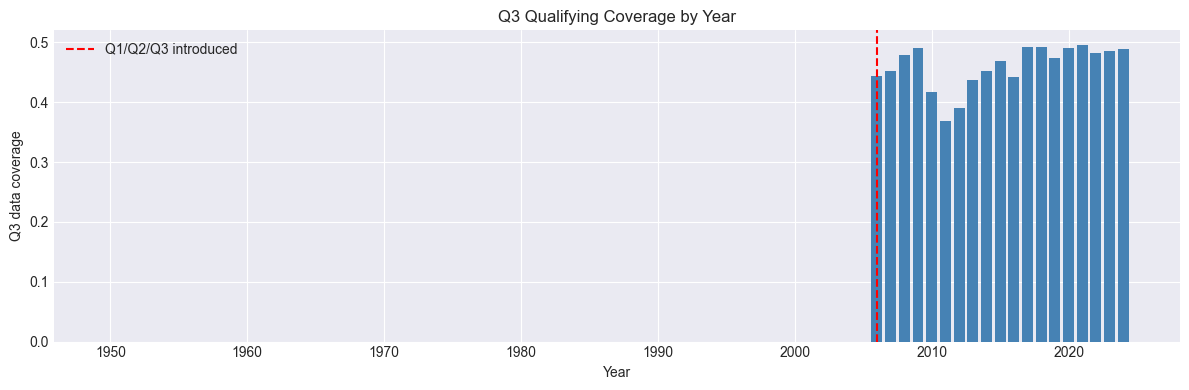

In [6]:
q3_coverage = (
    df.groupby("year")["q3_seconds"]
    .apply(lambda x: x.notna().mean())
    .reset_index()
    .rename(columns={"q3_seconds": "q3_coverage"})
)

fig, ax = plt.subplots(figsize=(12, 4))
ax.bar(q3_coverage["year"], q3_coverage["q3_coverage"], color="steelblue", width=0.8)
ax.axvline(2006, color="red", linestyle="--", label="Q1/Q2/Q3 introduced")
ax.set_xlabel("Year")
ax.set_ylabel("Q3 data coverage")
ax.set_title("Q3 Qualifying Coverage by Year")
ax.legend()
plt.tight_layout()
plt.savefig(FIGURES_DIR / "q3_coverage_by_year.png", dpi=150)
plt.show()

## Grid position distribution

Grid 0 means a pit-lane start — we recode that to 20 later.

In [7]:
df["grid"] = pd.to_numeric(df["grid"], errors="coerce")
print("Grid value counts (top 25):")
print(df["grid"].value_counts().head(25))
print(f"\nGrid == 0 (pit lane starts): {(df['grid'] == 0).sum()}")

Grid value counts (top 25):
grid
0     1638
1     1136
7     1135
4     1132
11    1132
9     1132
5     1132
3     1130
10    1130
8     1129
12    1127
6     1125
2     1125
13    1125
14    1120
15    1113
16    1100
17    1089
18    1050
19    1031
20     975
21     697
22     656
23     453
24     429
Name: count, dtype: int64

Grid == 0 (pit lane starts): 1638


## Drop columns we won't use

Keep only what's relevant for modelling. Raw time strings (`q1`, `q2`, `q3`) are replaced by `*_seconds`.

In [8]:
drop_cols = [
    "time",           # race finish time — only set for the winner
    "milliseconds",   # same info as time
    "fastestLap",     # lap number of fastest lap — not useful as feature
    "fastestLapTime", # raw string, not parsed
    "fastestLapSpeed",
    "q1", "q2", "q3", # replaced by q1_seconds etc.
    "number",         # car number, not predictive
]

# only drop columns that actually exist
drop_cols = [c for c in drop_cols if c in df.columns]
df_clean = df.drop(columns=drop_cols)
print(f"Dropped {len(drop_cols)} columns. Shape: {df_clean.shape}")

Dropped 9 columns. Shape: (26759, 29)


## Save cleaned dataframe

In [9]:
out_path = PROCESSED_DIR / "master_cleaned.csv"
df_clean.to_csv(out_path, index=False)
print(f"Saved: {out_path}  ({df_clean.shape[0]} rows, {df_clean.shape[1]} cols)")

Saved: C:\Users\Agam Katiyar\Projects\f1-ml-predictions\data\processed\master_cleaned.csv  (26759 rows, 29 cols)
